In [1]:
%load_ext autoreload
%autoreload 3

In [3]:
"""
Higher body correlations with k-copy RB

"""
import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(1)

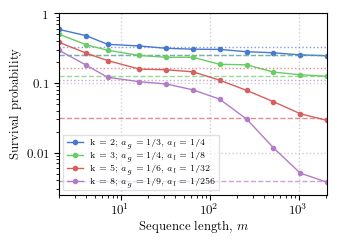

In [3]:
# plot asymptotic error rates vs num_qubits simulation
# Final mixed state asymptote:
# Final symmetric state asymptote:
num_q = [2, 3, 5, 8]
num_gates = [2, 4, 7, 16, 32, 64, 127, 256, 512, 1024, 2048]
pop_2 = [0.58932704, 0.48077473, 0.36079356, 0.34096596, 0.31573832, 0.3067054, 0.30447012, 0.28202406, 0.27258202, 0.25390676, 0.24667893]
pop_3 = [0.50299937, 0.3570375, 0.29574686, 0.24946642, 0.23448183, 0.23451108, 0.18594603, 0.18281402, 0.14363907, 0.1315057, 0.1251638]
pop_5 = [0.3846948, 0.27015725, 0.21078825, 0.15859023, 0.15531696, 0.14495696, 0.11005666, 0.07842725, 0.053984646, 0.036254227, 0.029027613]
pop_8 = [0.29539242, 0.1817384, 0.12113204, 0.10454461, 0.09695242, 0.07978952, 0.05878938, 0.030322364, 0.011740392, 0.005079949, 0.0037610682]

pops = [pop_2, pop_3, pop_5, pop_8]

fig_width = 1/2 * gs.get_fig_width() - gs.get_margin()
fig_height = (1/3)*gs.get_fig_width()
fig, ax1 = plt.subplots(1, 1, figsize=(fig_width, fig_height))
for i, q in enumerate(num_q):
    ax1.plot(num_gates, pops[i], label=f"k = {q}; $a_g = 1/{q+1}, a_l = 1/{2**q}$", marker="o", linestyle="-")
    upp_asymp = 1/(q+1)
    low_asymp = 1/(2**q)
    ax1.plot([min(num_gates), max(num_gates)], [upp_asymp, upp_asymp], color=gs.get_color(i), linestyle=":", alpha=gs.get_alpha(), label="")
    ax1.plot([min(num_gates), max(num_gates)], [low_asymp, low_asymp], color=gs.get_color(i), linestyle="--", alpha=gs.get_alpha(), label="")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(1/400, 1)
ax1.set_xlim(min(num_gates), max(num_gates))
ax1.set_xlabel("Sequence length, $m$")
ax1.set_ylabel("Survival probability")
ax1.set_yticks([1/100, 1/10, 1])
ax1.set_yticklabels([0.01, 0.1, 1])
ax1.legend(loc="lower left")

# save the figure
f_path = "..\\pdf_figure\\f3_asymp_sim.pdf"
fig.savefig(f_path)

In [4]:
# Plot single RB decay and fit to model
date = "2026-01-08"
sim_outcomes = [0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ]

rid = 88962 # injected random phase shifts with std = 0.06 turns
is_brights, cliff_lens, expected_outcomes = fh.get_rb_data(rid, date, sim_outcomes)
df = fh.three_qubit_analysis(is_brights, cliff_lens, expected_outcomes, rid, date, offset=0
)

<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
C:\Users\webbd\AppData\Local\Temp\ipykernel_4196\3003261277.py:39: SyntaxWarning: invalid escape sequence '\m'
  p1_name = "$\\varepsilon_\mathrm{corr}$"


Fitted parameters: [0.07294292 0.00038597 0.00038315 0.00261641]


<unknown>:39: SyntaxWarning: invalid escape sequence '\m'


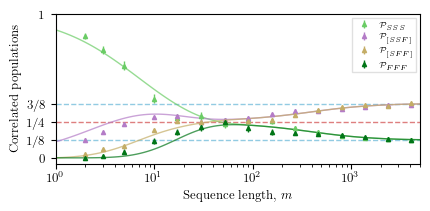

In [8]:
class ErrModelBase:
    name = "model"
    p1_name = "param1"
    p2_name = "param2"
    p3_name = "param3"
    p4_name = "param4"
    bounds = ([0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0])
    p0 = [0, 0, 0, 0]

    def model(self, x, p1, p2, p3, p4):
        raise NotImplementedError("Subclasses must implement the model method.")

    def fit_model(self, df):
        P000 = df["P000"].values
        P001 = df["P001"].values
        P011 = df["P011"].values
        P111 = df["P111"].values
        pops = [P000, P001, P011, P111]
        errs = [
            df["P000 Std"].values,
            df["P001 Std"].values,
            df["P011 Std"].values,
            df["P111 Std"].values,
        ]
        P = np.concatenate(pops)
        sigmas = np.concatenate(errs)
        # check for zero uncertainties and replace with small value to avoid issues in curve_fit
        for i in range(len(sigmas)):
            if sigmas[i] == 0:
                print(f"Warning: zero uncertainty for data point {i}, replacing with large value.")
                sigmas[i] = 1.0
        x = df["Clifford Length"]
        popt, pcov = curve_fit(self.model, x, P, sigma=sigmas, p0=self.p0, absolute_sigma=True, bounds=self.bounds)
        return popt, pcov

class Q3SO3Model(ErrModelBase):
    """ Random small SO3 rotations mode for two-qubit RB."""
    name = "SO3"
    p1_name = "$\\varepsilon_\mathrm{corr}$"
    p2_name = "$\\varepsilon_{1}$"
    p3_name = "$\\varepsilon_{2}$"
    p4_name = "$\\varepsilon_{3}$"
    bounds = ([0.0, 0.0, 0.0, 0.0], [10.0, 10.0, 10.0, 10.0])
    p0 = [0.1, 0.01, 0.01, 0.01]

    def model_stochastic(self, x, e_corr, e_1, e_2, e_3):
        """
        Correlated rotations model for two-qubit RB.
        """
        acorr = (1 - e_corr)**x
        a1 = (1 - e_1)**x
        a2 = (1 - e_2)**x
        a3 = (1 - e_3)**x
        b2q = a1*a2 + a1*a3 + a2*a3
        M1 = b2q
        M2 = 3*(a1 + a2 + a3) * acorr
        M3 = 2*b2q*acorr
        M4 = 3*a1*a2*a3*acorr
        P000 = 1/8 + (M1 + M2 + M3 + M4)/24
        P111 = 1/8 + (M1 - M2 + M3 - M4)/24
        P001 = 3/8 + (-M1 + M2 - M3 - 3*M4)/24
        P011 = 3/8 + (-M1 - M2 - M3 + 3*M4)/24
        P = np.concatenate([P000, P001, P011, P111])
        # check sum of probs = 1
        sum_probs = P000 + P001 + P011 + P111
        if not np.allclose(sum_probs, 1.00):
            raise ValueError("Probabilities do not sum to 1.")
        return P

    def model(self, x, e_corr, e_1, e_2, e_3):
        """
        Correlated rotations model for two-qubit RB.
        e_corr = theta^2/3
        """
        acorr1 = (1 - e_corr)**x
        acorr2 = (1 - 3*e_corr)**x
        acorr3 = (1 - 6*e_corr)**x
        a1 = (1 - e_1)**x
        a2 = (1 - e_2)**x
        a3 = (1 - e_3)**x
        b2q = a1*a2 + a1*a3 + a2*a3
        M1 = b2q
        M2 = 3*(a1 + a2 + a3) * acorr1
        M3 = 2*b2q*acorr2
        M4 = 6/5*a1*a2*a3*acorr3
        M5 = 9/5*a1*a2*a3*acorr1
        P000 = 1/8 + (M1 + M2 + M3 + M4 + M5)/24
        P111 = 1/8 + (M1 - M2 + M3 - M4 - M5)/24
        P001 = 3/8 + (-M1 + M2 - M3 - 3*M4-3*M5)/24
        P011 = 3/8 + (-M1 - M2 - M3 + 3*M4 + 3*M5)/24
        P = np.concatenate([P000, P001, P011, P111])
        # check sum of probs = 1
        sum_probs = P000 + P001 + P011 + P111
        if not np.allclose(sum_probs, 1.00):
            raise ValueError("Probabilities do not sum to 1.")
        return P

def plot_three_data(ax, df):
    m = Q3SO3Model()
    popt, pcov = m.fit_model(df)
    # print fitted parameters
    print(f"Fitted parameters: {popt}")

    x_min = 1
    x_max = 5000
    ax.hlines(3/8, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(1/8, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(1/4, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

    ax.set_yticks([0, 1/8, 1/4, 3/8,1])
    ax.set_yticklabels(["0", r"$1/8$", r"$1/4$", r"$3/8$","1"])
    ax.errorbar(df["Clifford Length"], df["P000"], yerr=df["P000 Std"], fmt="^", label="$\\mathcal{P}_{SSS}$", color=gs.get_color(1))
    ax.errorbar(df["Clifford Length"], df["P001"], yerr=df["P001 Std"], fmt="^", label="$\\mathcal{P}_{[SSF]}$", color=gs.get_color(3))
    ax.errorbar(df["Clifford Length"], df["P011"], yerr=df["P011 Std"], fmt="^", label="$\\mathcal{P}_{[SFF]}$", color=gs.get_color(4))
    ax.errorbar(df["Clifford Length"], df["P111"], yerr=df["P111 Std"], fmt="^", label="$\\mathcal{P}_{FFF}$", color="#017517")


    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
    reshape_fac = 4
    P_fit = m.model(x_fit, *popt).reshape(reshape_fac, -1)
    ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[1], color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[2], color=gs.get_color(4), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.04, 1.0)
    ax.set_xscale("log")

fig_width = gs.get_fig_width()*0.75
fig_height = gs.get_fig_width()*0.75/2

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

plot_three_data(ax, df)

ax.legend(loc="upper right")
ax.set_xlabel("Sequence length, $m$")
ax.set_ylabel("Correlated populations")
ax.grid(False)
plt.tight_layout()

f_path = "..\\..\\pdf_figure\\ch4\\f_app_3q.pdf"
fig.savefig(f_path)